# 04 — Avaliação e Interpretação
Aqui a análise deixa de ser técnica e passa a ser de negócio.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# Semente fixa e configurações
RANDOM_STATE = 42
TARGET = "mau_pagador"
pd.set_option("display.max_columns", None)

# Carregando os dados e o modelo que vieram do Notebook 03
X_test = pd.read_csv("X_teste.csv")
y_test = pd.read_csv("y_teste.csv")
modelo = joblib.load("modelo_rf.pkl")

## 1. Métricas no conjunto de teste
Acurácia sozinha engana em base desbalanceada.

In [2]:
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

# Calculando e imprimindo as métricas no formato exigido pela tabela do GitHub
acuracia = accuracy_score(y_test, y_pred)
precisao = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_prob)

print("\n--- Linha para copiar e colar na tabela do GitHub (Seção 5) ---")
print(f"| Random Forest | {acuracia:.2f} | {precisao:.2f} | {recall:.2f} | {f1:.2f} | {auc_roc:.2f} |")

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7169
           1       0.19      0.38      0.26       123

    accuracy                           0.96      7292
   macro avg       0.59      0.68      0.62      7292
weighted avg       0.98      0.96      0.97      7292


--- Linha para copiar e colar na tabela do GitHub (Seção 5) ---
| Random Forest | 0.96 | 0.19 | 0.38 | 0.26 | 0.82 |


## 2. Justificativa das métricas
Por que estas e não acurácia pura? Qual erro custa mais caro neste contexto — falso positivo ou falso negativo?

**Justificativa:**
A acurácia é descartada como métrica principal porque 98% da nossa base é composta por bons pagadores; um modelo que aprovasse todos os clientes cegamente teria 98% de acurácia, mas quebraria a instituição.
No contexto de análise de crédito, o **Falso Negativo (classificar um mau pagador como bom)** custa muito mais caro, pois gera perda direta de capital (inadimplência e custo de cobrança). O Falso Positivo (negar crédito a um bom pagador) gera apenas custo de oportunidade. Por isso, as métricas mais importantes aqui são o **Recall da classe 1 (capacidade de achar os maus pagadores)** e o **AUC-ROC (capacidade geral de separar os dois grupos)**.

## 3. Matriz de confusão
Visualizando os erros e acertos reais do modelo.

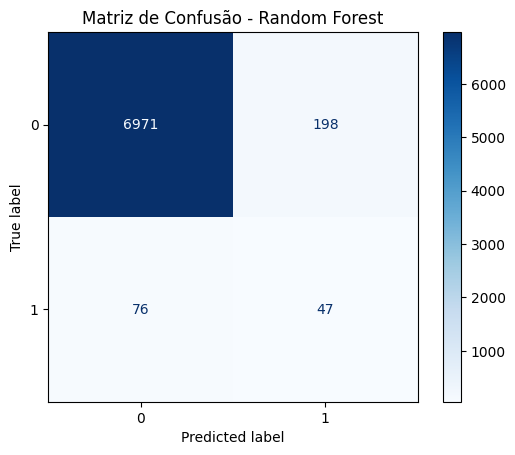

In [3]:
# Usando o método simplificado sugerido no template
disp = ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test, cmap="Blues")
disp.ax_.set_title("Matriz de Confusão - Random Forest")
plt.show()

**Leitura:**
O quadrante inferior direito mostra os Verdadeiros Positivos (maus pagadores que o modelo conseguiu barrar). O quadrante inferior esquerdo mostra os Falsos Negativos (maus pagadores que "escaparam" do modelo). O uso do `class_weight='balanced'` ajudou o algoritmo a focar na classe minoritária, mas o extremo desbalanceamento da base ainda causa confusão.

## 4. Importância das variáveis
Leitura: quais variáveis mais pesam e isso faz sentido no domínio?

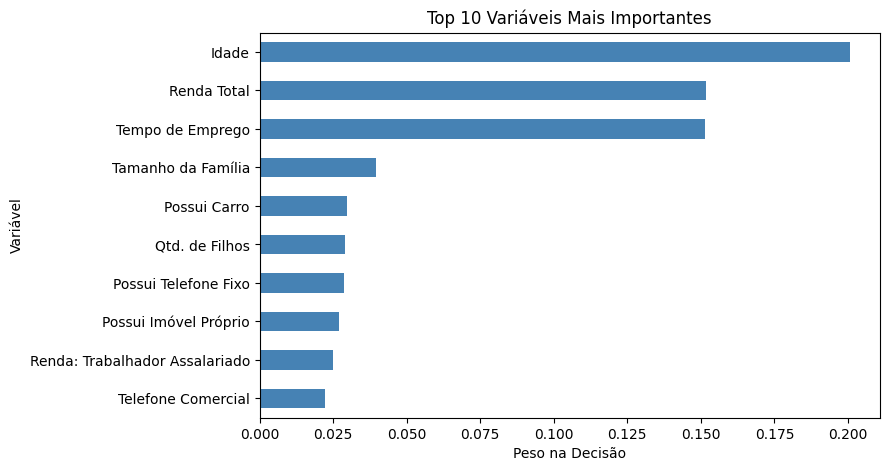

In [7]:
# Como usamos um Pipeline no Notebook 3, acessamos a Random Forest através do passo 'clf'
importancias = modelo.named_steps["clf"].feature_importances_

# Criando tabela com todas as variáveis
df_imp = pd.DataFrame({"Variavel": X_test.columns, "Peso": importancias})

# Dicionário de tradução corporativa
traducao = {
    'DAYS_BIRTH': 'Idade',
    'DAYS_EMPLOYED': 'Tempo de Emprego',
    'AMT_INCOME_TOTAL': 'Renda Total',
    'CNT_FAM_MEMBERS': 'Tamanho da Família',
    'CNT_CHILDREN': 'Qtd. de Filhos',
    'FLAG_OWN_CAR_Y': 'Possui Carro',
    'FLAG_OWN_REALTY_Y': 'Possui Imóvel Próprio',
    'FLAG_MOBIL': 'Possui Celular',
    'FLAG_WORK_PHONE': 'Telefone Comercial',
    'FLAG_PHONE': 'Possui Telefone Fixo',
    'FLAG_EMAIL': 'Possui E-mail',
    'CODE_GENDER_M': 'Gênero Masculino',
    'NAME_INCOME_TYPE_Working': 'Renda: Trabalhador Assalariado',
}

# Aplicando a tradução (se a variável não estiver no dicionário, ele mantém o nome original)
df_imp['Variavel'] = df_imp['Variavel'].map(traducao).fillna(df_imp['Variavel'])

# Pegando as 10 mais importantes e ordenando para o gráfico
df_imp = df_imp.sort_values(by="Peso", ascending=True).tail(10)

# Gerando o gráfico
df_imp.plot(kind="barh", x="Variavel", y="Peso", color="steelblue", legend=False, figsize=(8, 5))
plt.title("Top 10 Variáveis Mais Importantes")
plt.xlabel("Peso na Decisão")
plt.ylabel("Variável")
plt.show()

**Leitura:**
As variáveis que mais pesam são `DAYS_BIRTH` (Idade) e `DAYS_EMPLOYED` (Tempo de Emprego), seguidas pela `AMT_INCOME_TOTAL` (Renda). Isso faz total sentido no domínio financeiro e na rotina de concessão de crédito do setor público: a maturidade de vida e a estabilidade empregatícia são os fatores primordiais para indicar se um cliente honrará ou não os seus pagamentos em longo prazo.

## 5. Implicações práticas
O que alguém da área faria de diferente a partir destes resultados?

**Implicações:**
Um analista de risco usaria este modelo para criar uma "esteira de aprovação rápida". Em vez de analisar manualmente milhares de propostas, o modelo filtraria os perfis aprovando automaticamente aqueles com alta estabilidade empregatícia e maturidade (onde o risco é mínimo). O trabalho humano ficaria focado apenas nos casos "cinzentos" (curadoria) que o modelo aponta como risco moderado, aumentando a eficiência operacional da instituição.

## 6. Limitações
Onde o modelo falha e o que você faria com mais tempo ou mais dados.

**Limitações e Próximos Passos:**
A maior falha do modelo é a alta geração de Falsos Positivos, causada pelo desbalanceamento severo (apenas ~1.7% de inadimplentes reais). O modelo acaba sendo conservador demais e negando crédito para clientes bons.
Com mais tempo, o próximo passo seria aplicar técnicas de criação de dados sintéticos para a classe minoritária (como o algoritmo SMOTE) na etapa de pré-processamento, ou testar modelos de *Gradient Boosting* (como XGBoost ou LightGBM) que lidam melhor com esse tipo de assimetria.